# 03 Training on the block split

Goal: train a model on the block split from notebook 02 and measure how well it generalises to scans it has not seen.

Setup:

- MobileNetV3-Large, pretrained on ImageNet, with the last layer replaced by three outputs
- AdamW optimiser, learning rate 1e-4, weight decay 1e-4, batch size 32
- Images resized to 224 x 224 and normalised with ImageNet statistics, no augmentation

In [33]:
import csv
from pathlib import Path
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
data_dir = Path("../data/Original CT Scans")
split_file = Path("../splits/block_split.csv")

In [34]:
train_items, val_items, test_items = [], [], []

with open(split_file, newline="") as file:
    reader = csv.DictReader(file)
    for row in reader:
        item = (data_dir / row["path"], row["label"])
        if row["split"] == "train":
            train_items.append(item)
        elif row["split"] == "val":
            val_items.append(item)
        elif row["split"] == "test":
            test_items.append(item)

print(len(train_items), len(val_items), len(test_items))
print(train_items[0])
print(train_items[0][0].exists())

13778 2949 2958
(WindowsPath('../data/Original CT Scans/nCT/nCT2.jpg'), 'nCT')
True


In [35]:
class_to_idx = {"nCT": 0, "NiCT": 1, "pCT": 2}

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CTDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        path, label = self.items[index]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, class_to_idx[label]

In [36]:
train_dataset = CTDataset(train_items, train_transform)
print(len(train_dataset))

image, label = train_dataset[0]
print(image.shape, label)
print(image.min(), image.max())

13778
torch.Size([3, 224, 224]) 0
tensor(-1.7754) tensor(2.2217)


In [37]:
print(train_dataset.transform)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [38]:
val_dataset = CTDataset(val_items, transform)
test_dataset = CTDataset(test_items, transform)
print(len(val_dataset), len(test_dataset))


2949 2958


In [39]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_loader), len(val_loader), len(test_loader))

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)
print(labels)

431 93 93
torch.Size([32, 3, 224, 224]) torch.Size([32])
tensor([0, 1, 1, 1, 0, 0, 0, 1, 0, 2, 0, 2, 2, 1, 2, 0, 1, 2, 2, 1, 0, 0, 0, 2,
        1, 1, 1, 0, 0, 1, 2, 0])


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
print(model.classifier)

cuda
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)


In [41]:
model.classifier[3] = nn.Linear(1280, 3)
model = model.to(device)

print(sum(p.numel() for p in model.parameters()))

4205875


In [42]:
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))

print(outputs.shape)
print(torch.softmax(outputs[0], dim=0))

torch.Size([32, 3])
tensor([0.2638, 0.4947, 0.2415], device='cuda:0')


## Sanity check: overfitting one batch

Before training on all data, I train 20 steps on a single batch. If data, model, loss and optimiser are connected correctly, the loss should drop. It went from 1.14, close to the 1.10 expected for random guessing between three classes, to 0.014.

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

images_gpu = images.to(device)
labels_gpu = labels.to(device)

model.train()
for step in range(20):
    optimizer.zero_grad()
    outputs = model(images_gpu)
    loss = criterion(outputs, labels_gpu)
    loss.backward()
    optimizer.step()
    print(step, round(loss.item(), 4))

0 1.1279
1 0.9655
2 0.8114
3 0.6787
4 0.5765
5 0.4559
6 0.3737
7 0.3118
8 0.2438
9 0.1962
10 0.1471
11 0.1124
12 0.086
13 0.062
14 0.0482
15 0.0333
16 0.024
17 0.0167
18 0.0135
19 0.0107


In [ ]:
def train_one_epoch(model, loader):
    model.train()
    model.features.eval()
    total_loss = 0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [45]:
def evaluate(model,loader):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [46]:
torch.manual_seed(42)

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
model.classifier[3] = nn.Linear(1280, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

num_epochs = 10
best_val_loss = float("inf")
history = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    history.append((train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch + 1}: train loss {train_loss:.4f}, acc {train_acc:.2%} | val loss {val_loss:.4f}, acc {val_acc:.2%}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), output_dir / "best_model_aug.pth")
        print("  Saved best model")

Epoch 1: train loss 0.0802, acc 97.13% | val loss 0.8138, acc 69.45%
  Saved best model
Epoch 2: train loss 0.0191, acc 99.36% | val loss 2.9234, acc 60.90%
Epoch 3: train loss 0.0133, acc 99.56% | val loss 2.5386, acc 62.39%
Epoch 4: train loss 0.0097, acc 99.71% | val loss 2.4711, acc 63.41%
Epoch 5: train loss 0.0088, acc 99.66% | val loss 4.0855, acc 59.31%
Epoch 6: train loss 0.0089, acc 99.71% | val loss 2.3010, acc 63.99%
Epoch 7: train loss 0.0056, acc 99.82% | val loss 3.9690, acc 62.43%
Epoch 8: train loss 0.0082, acc 99.75% | val loss 3.1788, acc 62.39%
Epoch 9: train loss 0.0082, acc 99.70% | val loss 3.4849, acc 59.58%
Epoch 10: train loss 0.0068, acc 99.75% | val loss 2.4448, acc 62.29%


**Findings**

- Training accuracy reached 99.9%, but validation accuracy stayed between 59% and 64%.
- The lowest validation loss (2.07, accuracy 63.2%) was reached after epoch 2. Later epochs did not improve it, so I stopped training during epoch 8. The model from epoch 2 is saved as `best_model.pth`.
- The model overfits from the start: it learns the training scans, but not a pattern that transfers to new scans.

## Checking for a bug

A gap this large could also be caused by a bug in the evaluation code. To rule this out, I evaluate the training set with the same `evaluate` function.

In [47]:
train_loss_eval, train_acc_eval = evaluate(model, train_loader)
print(f"Train in eval mode: loss {train_loss_eval:.4f}, acc {train_acc_eval:.2%}")

Train in eval mode: loss 0.0028, acc 99.89%


In [53]:
def predict(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.tolist())
    return all_labels, all_preds

model.load_state_dict(torch.load(output_dir / "best_model_aug.pth", map_location=device))
y_true, y_pred = predict(model, val_loader)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["nCT", "NiCT", "pCT"]))

[[734 195 567]
 [  0 854   0]
 [ 32 107 460]]
              precision    recall  f1-score   support

         nCT       0.96      0.49      0.65      1496
        NiCT       0.74      1.00      0.85       854
         pCT       0.45      0.77      0.57       599

    accuracy                           0.69      2949
   macro avg       0.71      0.75      0.69      2949
weighted avg       0.79      0.69      0.69      2949



802


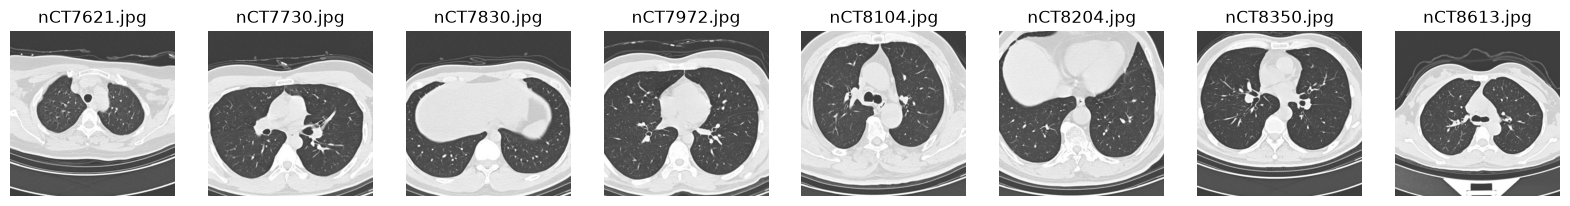

In [49]:
wrong = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t == 0 and p == 2]
print(len(wrong))

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, i in zip(axes, wrong[::len(wrong) // 8][:8]):
    path, label = val_items[i]
    ax.imshow(Image.open(path), cmap="gray")
    ax.set_title(path.name)
    ax.axis("off")
plt.show()

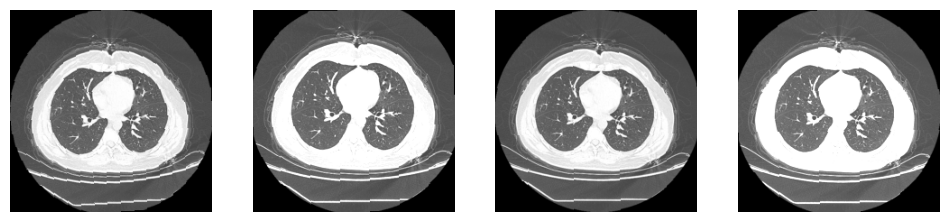

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax in axes:
    image, label = train_dataset[0]
    ax.imshow(image[0], cmap="gray")
    ax.axis("off")
plt.show()

**Findings**

- In eval mode, the model reaches 96.1% on the training set, so the evaluation code works. The small gap with training mode is not enough to explain the validation result.
- `NiCT`: 851 of 854 validation slices correct.
- `pCT`: 479 of 599 correct.
- `nCT`: only 549 of 1,496 correct. 711 normal slices are predicted as COVID-19 positive, so precision for `pCT` is only 40%.
- The misclassified normal slices look normal to me: dark lung fields without the hazy patches seen in `pCT`. The model seems to react to something other than the disease pattern.

Note: these checks used the model in memory after training was interrupted, not the saved model from epoch 2.